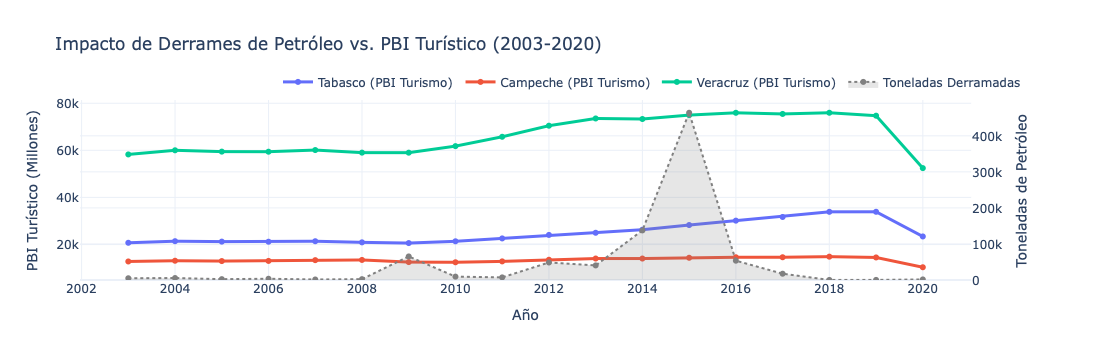

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. Cargar datos (ajustamos la ruta al archivo local)
df = pd.read_csv('../data/turismo_derrames.csv')

# 2. Limpieza de datos: Convertir la columna de toneladas a numérico
# Eliminamos las comas de los strings y convertimos a float
df['Cantidad reportada (toneladas)'] = df['Cantidad reportada (toneladas)'].str.replace(',', '').astype(float)

# Crear figura con eje secundario
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 3. Agregar líneas de PBI por estado (Eje Y Primario)
estados = ['Tabasco (PBI Turismo)', 'Campeche (PBI Turismo)', 'Veracruz (PBI Turismo)']
colores = ['#636EFA', '#EF553B', '#00CC96']

for estado, color in zip(estados, colores):
    fig.add_trace(
        go.Scatter(x=df['anio'], y=df[estado], name=estado,
                   line=dict(width=3, color=color), mode='lines+markers'),
        secondary_y=False,
    )

# 4. Agregar el impacto de derrames (Eje Y Secundario)
# Usamos un gráfico de área para resaltar visualmente el evento
fig.add_trace(
    go.Scatter(x=df['anio'], y=df['Cantidad reportada (toneladas)'], 
               name='Toneladas Derramadas',
               fill='tozeroy', fillcolor='rgba(128, 128, 128, 0.2)',
               line=dict(color='gray', dash='dot')),
    secondary_y=True,
)

# Configuración de diseño
fig.update_layout(
    title='Impacto de Derrames de Petróleo vs. PBI Turístico (2003-2020)',
    xaxis_title='Año',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template='plotly_white',
    hovermode='x unified'
)

# Nombres de ejes
fig.update_yaxes(title_text="PBI Turístico (Millones)", secondary_y=False)
fig.update_yaxes(title_text="Toneladas de Petróleo", secondary_y=True)

# Mostrar gráfico
fig.show()

In [7]:
df

,anio,Tabasco (PBI Turismo),Campeche (PBI Turismo),Veracruz (PBI Turismo),Número de derrames,Cantidad reportada (toneladas)
0,2003,20734.72885,12791.82474,58265.34516,431,4824.00
1,2004,21407.57126,13106.11582,60023.95003,517,5478.00
2,2005,21225.32855,12965.67334,59455.50040,359,2321.00
3,2006,21185.30421,13031.83574,59424.48395,277,3432.92
4,2007,21391.63097,13353.89335,60122.44814,206,1439.00
5,2008,20918.09550,13443.95400,59026.92042,171,2327.00
6,2009,20609.60381,12536.24370,59009.58454,123,65332.00
7,2010,21360.37265,12453.38194,61787.88543,72,9373.00
8,2011,22586.63298,12826.78913,65761.47932,106,7225.00
9,2012,24066.83210,13523.19669,70467.00459,182,48597.00
